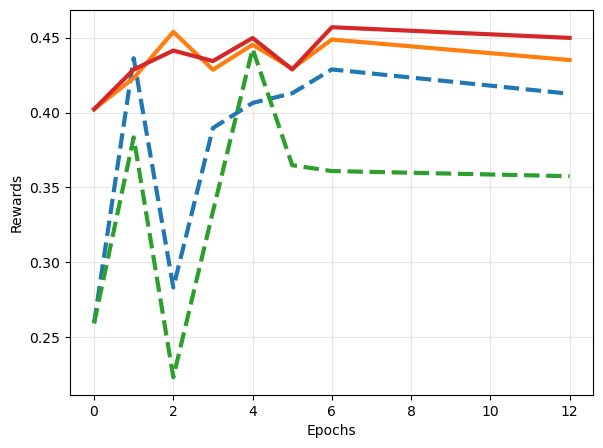

In [ ]:
import os, shutil, subprocess,sys
import torch
import json
import numpy as np
import matplotlib.pyplot as plt

def read_jsonl_key_to_list(path: str, key: str):
    vals = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                d = json.loads(line)
            except json.JSONDecodeError:
                continue
            if not isinstance(d, dict):
                continue
            v = d.get(key, None)
            v = float(v) if v is not None else None
            if v is not None:
                vals.append(v)
    last_val = vals[-1]
    last_5_val_ave = sum(vals[-5:]) / 5
    last_3_val_ave = sum(vals[-3:]) / 3
    return vals, last_val, last_5_val_ave, last_3_val_ave

epochs = [0,1,2,3,4,5,6,12]
fileName_1 = "qwen_r0s0c1_noCur"
fileName_2 = "qwen_r0s0c1_cCur2"
path_1 = f"../runs/{fileName_1}/metrics.jsonl"
path_2 = f"../runs/{fileName_2}/metrics.jsonl"
p_rewards_1 = read_jsonl_key_to_list(path_1, "p_eval_raw_reward")[0]
q_rewards_1 = read_jsonl_key_to_list(path_1, "q_eval_raw_reward")[0]
p_rewards_on_q_1 = read_jsonl_key_to_list(path_1, "p_eval_on_qsrc_raw_reward")[0]
q_rewards_on_p_1 = read_jsonl_key_to_list(path_1, "q_reward_on_xsum")[0]

p_rewards_2 = read_jsonl_key_to_list(path_2, "p_eval_raw_reward")[0]
q_rewards_2 = read_jsonl_key_to_list(path_2, "q_eval_raw_reward")[0]
p_rewards_on_q_2 = read_jsonl_key_to_list(path_2, "p_eval_on_qsrc_raw_reward")[0]
q_rewards_on_p_2 = read_jsonl_key_to_list(path_2, "q_reward_on_xsum")[0]

fig, ax = plt.subplots(figsize=(6.75, 5))
linewidth=3
plt.plot(epochs, p_rewards_on_q_1, label='p_rewards_on_qsrc_1', linestyle='--', linewidth=linewidth)
plt.plot(epochs, q_rewards_on_p_1, label='q_rewards_on_p_1', linewidth=linewidth)
plt.plot(epochs, p_rewards_on_q_2, label='p_rewards_on_qsrc_2', linestyle='--', linewidth=linewidth)
plt.plot(epochs, q_rewards_on_p_2, label='q_rewards_on_p_2', linewidth=linewidth)
plt.xlabel('Epochs')
plt.ylabel('Rewards')
# plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
fig.savefig("qwen_cross_test.svg", dpi=1800, format="svg") 

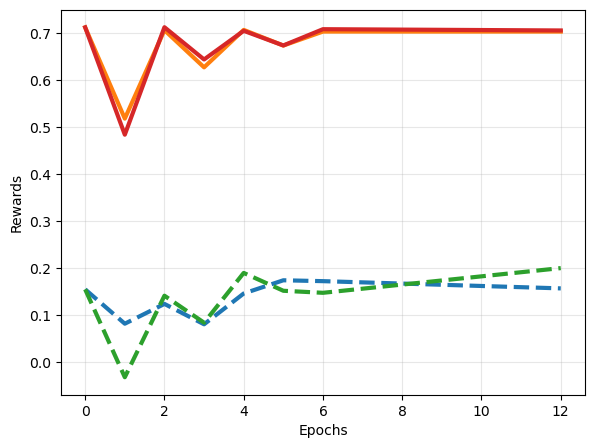

In [ ]:
fig, ax = plt.subplots(figsize=(6.75, 5))
linewidth=3
plt.plot(epochs, p_rewards_1, label='p_rewards_1', linestyle='--', linewidth=linewidth)
plt.plot(epochs, q_rewards_1, label='q_rewards_1', linewidth=linewidth)
plt.plot(epochs, p_rewards_2, label='p_rewards_2', linestyle='--', linewidth=linewidth)
plt.plot(epochs, q_rewards_2, label='q_rewards_2', linewidth=linewidth)
plt.xlabel('Epochs')
plt.ylabel('Rewards')
# plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
fig.savefig("qwen_self_test.svg", dpi=1800, format="svg")   